# Python Assignment 16 :Recommendation system 

In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

In [25]:
df = pd.read_csv("anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [26]:
df.shape

(12294, 7)

In [27]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [29]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [30]:
df.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [31]:
df['genre'].fillna("Unknown", inplace=True)

C:\Users\Thasin\AppData\Local\Temp\ipykernel_21892\2598542774.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna("Unknown", inplace=True)


In [32]:
df['type'].fillna(df['type'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].mean(), inplace=True)


C:\Users\Thasin\AppData\Local\Temp\ipykernel_21892\3906432461.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type'].fillna(df['type'].mode()[0], inplace=True)
C:\Users\Thasin\AppData\Local\Temp\ipykernel_21892\3906432461.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [36]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
df['episodes'].fillna(df['episodes'].median(), inplace=True)


C:\Users\Thasin\AppData\Local\Temp\ipykernel_21892\1705450419.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['episodes'].fillna(df['episodes'].median(), inplace=True)


In [39]:
df.drop_duplicates(inplace=True)

In [41]:
df.sort_values(by='rating', ascending=False).head(10)


,anime_id,name,genre,type,episodes,rating,members
10464,33662,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",Movie,1.0,10.00,13
10400,30120,Spoon-hime no Swing Kitchen,"Adventure, Kids",TV,2.0,9.60,47
9595,23005,Mogura no Motoro,Slice of Life,Movie,1.0,9.50,62
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
9078,33607,Kahei no Umi,Historical,Movie,1.0,9.33,44
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
10786,26313,Yakusoku: Africa Mizu to Midori,"Drama, Kids",OVA,1.0,9.25,53
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


In [42]:
df.sort_values(by='members', ascending=False).head(10)


,anime_id,name,genre,type,episodes,rating,members
40,1535,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37.0,8.71,1013917
86,16498,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25.0,8.54,896229
804,11757,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
159,6547,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13.0,8.39,717796
19,1575,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,25.0,8.83,715151
841,20,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220.0,7.81,683297
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
445,10620,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26.0,8.07,657190
131,4224,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817


In [43]:
df['genre'].str.split(',').explode().value_counts().head(10)


genre
Comedy       3193
Action       2845
 Sci-Fi      1986
 Fantasy     1815
 Shounen     1663
Adventure    1457
 Comedy      1452
 Romance     1371
 Kids        1213
 School      1170
Name: count, dtype: int64

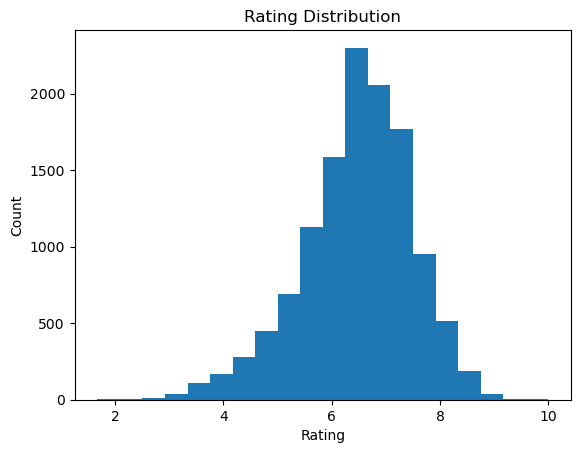

In [45]:

plt.hist(df['rating'], bins=20)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

genre_matrix = tfidf.fit_transform(df['genre'])


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['rating', 'members', 'episodes']] = scaler.fit_transform(
    df[['rating', 'members', 'episodes']]
)


In [53]:
from scipy.sparse import hstack

# numerical features
num_features = df[['rating', 'members', 'episodes']].values

# combine with genre matrix
final_features = hstack([genre_matrix, num_features])
final_features

<COOrdinate sparse matrix of dtype 'float64'
	with 71683 stored elements and shape (12294, 50)>

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(genre_matrix, genre_matrix)


In [55]:
indices = pd.Series(df.index, index=df['name']).drop_duplicates()


In [56]:
def recommend_anime(title, cosine_sim=cosine_sim, threshold=0.5):
    
    if title not in indices:
        return "Anime not found"
    
    idx = indices[title]
    
    # get similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    # sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # remove itself
    sim_scores = sim_scores[1:]
    
    # apply threshold
    sim_scores = [i for i in sim_scores if i[1] >= threshold]
    
    # get top results
    anime_indices = [i[0] for i in sim_scores[:10]]
    
    return df['name'].iloc[anime_indices]


In [57]:
recommend_anime("Naruto")


615                                    Naruto: Shippuuden
841                                                Naruto
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
2458                 Naruto Shippuuden: Sunny Side Battle
2997    Naruto Soyokazeden Movie: Naruto to Mashin to ...
7628                              Kyutai Panic Adventure!
784            Naruto: Shippuuden Movie 6 - Road to Ninja
Name: name, dtype: object

In [58]:
recommend_anime("Naruto", threshold=0.7)


615                                    Naruto: Shippuuden
841                                                Naruto
1103    Boruto: Naruto the Movie - Naruto ga Hokage ni...
1343                                          Naruto x UT
1472          Naruto: Shippuuden Movie 4 - The Lost Tower
1573    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
2458                 Naruto Shippuuden: Sunny Side Battle
2997    Naruto Soyokazeden Movie: Naruto to Mashin to ...
7628                              Kyutai Panic Adventure!
784            Naruto: Shippuuden Movie 6 - Road to Ninja
Name: name, dtype: object